In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["plasma"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')




In [81]:
def read_data_from_file(filepath):
    """
    Reads the data file and extracts all data sets
    
    Args:
        filepath: Path to the data file
    
    Returns:
        Dictionary with data set numbers as keys and (x, y) tuples as values
    """
    datasets = {}
    current_dataset = None
    x_data = []
    y_data = []
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            
            # Skip empty lines
            if not line:
                continue
            
            # Check if this is a dataset header
            if line.startswith('Data set'):
                # Save previous dataset if exists
                if current_dataset is not None and x_data:
                    datasets[current_dataset] = (np.array(x_data), np.array(y_data))
                
                # Extract dataset number
                current_dataset = int(line.split()[-1])
                x_data = []
                y_data = []
            
            # Skip title line
            elif line.startswith('Multiple'):
                continue
            
            # Parse data line
            else:
                try:
                    parts = line.split()
                    if len(parts) == 2:
                        x_data.append(float(parts[0]))
                        y_data.append(float(parts[1]))
                except ValueError:
                    # Skip lines that can't be parsed
                    print("skipped line with values ", parts)
                    continue
        
        # Don't forget the last dataset
        if current_dataset is not None and x_data:
            datasets[current_dataset] = (np.array(x_data), np.array(y_data))
    
    return datasets

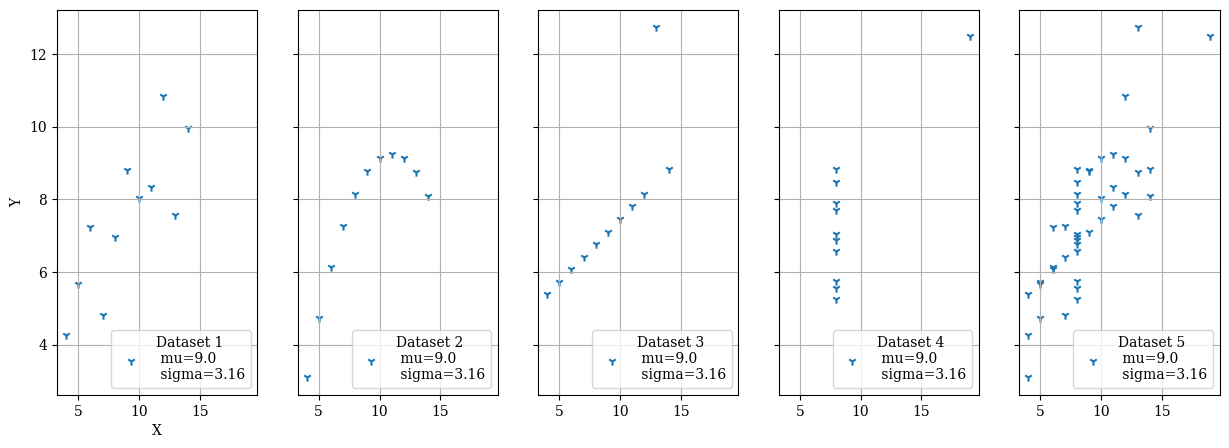

In [82]:
#reading in the file and splitting it in 5 seperate datasets

file_path = 'FranksNumbers.txt'

dataset_nr=read_data_from_file(file_path)

fig,ax=plt.subplots(1,5, figsize = (15,5),sharey=True, sharex=True)



ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')

for i in range(0,5):
    mu=np.mean(dataset_nr[i+1][0])
    s=np.std(dataset_nr[i+1][0])
    ax[i].scatter(dataset_nr[i+1][0],dataset_nr[i+1][1], label=f"Dataset {i+1}\n mu={mu:3.3}\n sigma={s:3.3}", marker=my_marker)
    ax[i].legend(loc='lower right')
    ax[i].grid()



In [ ]:
def pearsons_chi2(observed_array, expected_array,sigma_array):
    
    mask=(sigma_array!=0)
    #print(mask)
    if len(sigma_array[~mask])!=0:
        print("chi2: some values were masked")
        print(sigma_array[mask])

    #print(observed_array[mask],expected_array[mask],sigma_array[mask])
    chi2=np.sum((observed_array[mask]-expected_array[mask])**2/sigma_array[mask]**2)

    return chi2

with sigma=sqrt(y_expected)

In [105]:
def fct(x):
    y=x*0.48 + 3.02
    return y


for i in range(1,6):

    y_exp=fct(np.array(dataset_nr[i][0]))
    #print(y_exp)
    print(pearsons_chi2(np.array(dataset_nr[i][1]),y_exp,np.sqrt(y_exp)))

1.886825303845903
2.0715758463593357
1.5545390861808746
2.0429349282664355
7.555875164652551


with sigma=+-1.22

In [107]:
for i in range(1,6):

    y_exp=fct(np.array(dataset_nr[i][0]))
    #print(y_exp)
    s=np.full_like(y_exp,1.22)
    print(pearsons_chi2(np.array(dataset_nr[i][1]),y_exp,s))

9.46781779091642
9.476686374630479
9.460225745767271
9.453708680462244
37.85843859177643


In [85]:
def read_data_from_file_into_df(filepath):
    """
    Reads the data file and extracts all data sets
    
    Args:
        filepath: Path to the data file
    
    Returns:
        pandas DataFrame
    """
    datasets = {}
    current_dataset = None
    x_data = []
    y_data = []
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            
            # Skip empty lines
            if not line:
                continue
            
            # Check if this is a dataset header
            if line.startswith('Data set'):
                # Save previous dataset if exists
                if current_dataset is not None and x_data:
                    datasets[current_dataset] = (np.array(x_data), np.array(y_data))
                
                # Extract dataset number
                current_dataset = int(line.split()[-1])
                x_data = []
                y_data = []
            
            # Skip title line
            elif line.startswith('Multiple'):
                continue
            
            # Parse data line
            else:
                try:
                    parts = line.split()
                    if len(parts) == 2:
                        x_data.append(float(parts[0]))
                        y_data.append(float(parts[1]))
                except ValueError:
                    # Skip lines that can't be parsed
                    print("skipped line with values ", parts)
                    continue
        
        # Don't forget the last dataset
        if current_dataset is not None and x_data:
            datasets[current_dataset] = (np.array(x_data), np.array(y_data))
    
    return datasets

## second dataset aruj.txt

In [86]:
def read_aruj_data(filepath, dataset=None):
    """
    Reads aruj.txt file and converts to pandas DataFrame
    
    Args:
        filepath (str): Path to the aruj.txt file
        dataset (str, optional): Filter for specific dataset ('d', 'a', 'h', 'v')
                                If None, returns all data
    
    Returns:
        pandas.DataFrame: DataFrame with columns ['dataset', 'x', 'y']
    
    Examples:
        # Get all data
        df = read_aruj_data('aruj.txt')
        
        # Get only dataset 'd'
        df_d = read_aruj_data('aruj.txt', dataset='d')
        
        # Get only dataset 'a'
        df_a = read_aruj_data('aruj.txt', dataset='a')
    """
    # Read the file using pandas - it's space/tab delimited
    df = pd.read_csv(filepath, sep=r'\s+', engine='python')
    
    # If specific dataset requested, filter
    if dataset is not None:
        if dataset not in df['dataset'].unique():
            available = df['dataset'].unique().tolist()
            raise ValueError(f"Dataset '{dataset}' not found. Available: {available}")
        df = df[df['dataset'] == dataset].reset_index(drop=True)
    
    return df

In [87]:
#reading in the file and splitting it in 5 seperate datasets

file_path = 'aruj.txt'

dataset_aruj=read_aruj_data(file_path)


dataset_aruj#[dataset_aruj['dataset']=='d']



,dataset,x,y
0,d,55.384600,97.179500
1,d,51.538500,96.025600
2,d,46.153800,94.487200
3,d,42.820500,91.410300
4,d,40.769200,88.333300
...,...,...,...
563,v,30.487392,19.779470
564,v,89.500180,31.978917
565,v,50.410272,98.628369
566,v,50.325924,94.994631


In [88]:
np.mean(dataset_aruj['x'])


np.float64(54.26518550954577)

In [124]:
#fig,ax=plt.subplots(1,5, figsize = (15,5),sharey=True, sharex=True)



#ax[0].set_xlabel('X')
#ax[0].set_ylabel('Y')

#df=dataset_aruj['dataset'=='d']
#print(df)


for x in dataset_aruj[['x','y']]:
    print("dataset",x)

dataset_aruj.loc[dataset_aruj['dataset']=='d','x']
"""
for x,y in zip(df['x'],df['y']):
    print("dataset",x,y)

for i in range(0,5):
    mu=np.mean(dataset_nr[i+1][0])
    s=np.std(dataset_nr[i+1][0])
    ax[i].scatter(dataset_nr[i+1][0],dataset_nr[i+1][1], label=f"Dataset {i+1}\n mu={mu:3.3}\n sigma={s:3.3}", marker=my_marker)
    ax[i].legend(loc='lower right')
    ax[i].grid()"""



dataset x
dataset y


'\nfor x,y in zip(df[\'x\'],df[\'y\']):\n    print("dataset",x,y)\n\nfor i in range(0,5):\n    mu=np.mean(dataset_nr[i+1][0])\n    s=np.std(dataset_nr[i+1][0])\n    ax[i].scatter(dataset_nr[i+1][0],dataset_nr[i+1][1], label=f"Dataset {i+1}\n mu={mu:3.3}\n sigma={s:3.3}", marker=my_marker)\n    ax[i].legend(loc=\'lower right\')\n    ax[i].grid()'